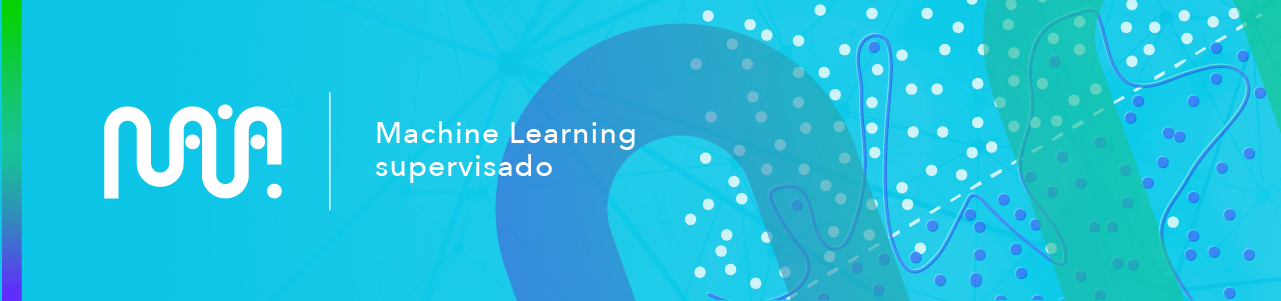
# Taller 4. Selección de modelos
***MLS. Machine learning supervisado***
<br>***Semana 4, Taller:*** *Selección de modelo y regularización*
<br> **Profesor:** *Fernando Lozano* - **Autor Notebook:** *Mónica Gantiva*



## Introducción
### Descripción
Este *jupyter notebook* contiene el material necesario para el desarrollo del Taller calificable de la Semana 4 del curso *MLS: Machine learning supervisado*. En esta tarea usted deberá solucionar un problema de clasificación binaria aplicando varios modelos y seleccionando el más conveniente.

#### Objetivos de Aprendizaje
<br>Identificar overfitting y underfitting en un modelo de aprendizaje supervisado. 
<br>Seleccionar apropiadamente la complejidad de un modelo en aprendizaje supervisado. 


### Metodología
En este taller se abordará un poblema aplicado de clasificación binaria para el cual usted deberá tomar dos modelos de machine learning propuestos y mejorar su desempeño. Para ello emplee las celdas que tienen la siguiente notación.

In [ ]:
# =====================================================
# COMPLETAR ===========================================
# 

# =====================================================

Así mismo, usted deberá análizar los resultados obtenidos para cada modelo. Para ello, responda las preguntas que se presentarán durante el taller. Dispondra de celdas con la siguiente notación para escribir su análisis:

***Respuesta:***

### Problema aplicado: clasificación de reservas de un hotel


En la industria hotelera es deseable estimar si un cliente cumplirá con la reservación previamente hecha. En este caso, se tiene una base de datos con la información del comportamiento de clientes que han realizado reservaciones en un hotel y el cumplimiento o cancelación de dicha reserva. En esta actividad se implementarán árboles de decisión y random forest para  predecir si un cliente cancelará o no su reserva y clasificar el estado de su reserva según el comportamiento que presente. La base de datos usada ha sido tomada de [1]
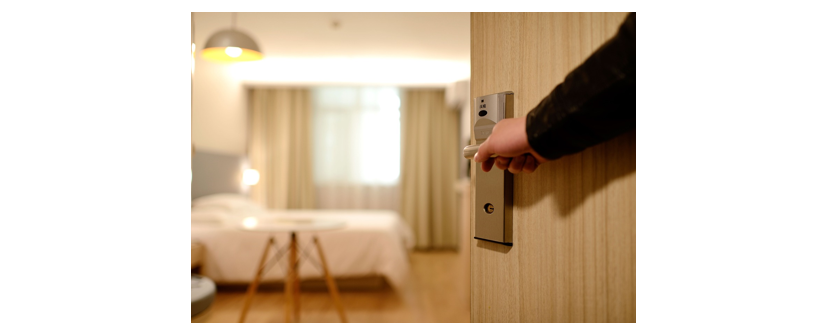

 Imagen tomada de [2]


***referencias***
<br>[1]https://www.kaggle.com/datasets/gauravduttakiit/reservation-cancellation-prediction
<br>[2]https://pixabay.com/es/photos/hotel-habitaci%C3%B3n-nuevo-producto-1330850/

#### Inicialización


In [1]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns

#### Cargamos los datos

In [2]:
datos_train = pd.read_csv('train.csv')
datos_train.head()

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,0,2,0,0,2,1,0,0,9,2018,1,14,1,1,11,0,67.50,0,0
1,1,2,0,1,2,0,0,0,117,2018,7,29,0,0,0,0,72.25,0,0
2,2,2,0,0,1,0,0,0,315,2018,12,2,0,0,0,0,52.00,0,0
3,3,1,0,0,2,1,0,0,32,2018,12,1,1,0,0,0,56.00,0,0
4,4,2,0,1,0,0,0,0,258,2018,10,16,0,0,0,0,100.00,0,1


Podemos ver que el archivo contiene los diferentes atributos de los detalles de la reserva de los clientes. El diccionario de datos detallado se proporciona a continuación.

* no_of_adults: Número de adultos
* no_of_children Número de niños
* no_of_weekend_nights: Número de noches de fin de semana (sábado o domingo) que el huésped se hospedó o reservó para quedarse en el hotel
* no_of_week_nights: Número de noches de la semana (lunes a viernes) que el huésped se hospedó o reservó para quedarse en el hotel
* type_of_meal_plan: Tipo de plan de comidas reservado por el cliente:
* required_car_parking_space: ¿Necesita el cliente una plaza de aparcamiento? (0 - No, 1 - Sí)
* room_type_reservated: Tipo de habitación reservada por el cliente. Los valores son cifrados (codificados) por INN Hotels.
* lead_time: Número de días entre la fecha de reserva y la fecha de llegada
* arrival_year: año de la fecha de llegada
* arrival_month: Mes de la fecha de llegada
* arrival_date: Fecha del mes
* market_segment_type: Designación del segmento de mercado.
* repeated_guest: ¿El cliente es un invitado repetido? (0 - No, 1 - Sí)
* no_of_previous_cancellations: número de reservas anteriores que fueron canceladas por el cliente antes de la reserva actual
* no_of_previous_bookings_not_canceled: Número de reservas anteriores no canceladas por el cliente antes de la reserva actual
* avg_price_per_room: Precio medio por día de la reserva; Los precios de las habitaciones son dinámicos. (en euros)
* no_of_special_requests: número total de solicitudes especiales realizadas por el cliente (por ejemplo, piso alto, vista desde la habitación, etc.)
* booking_status: Bandera que indica si la reserva fue cancelada o no.

La última columna corresponde al estado de la reserva, siendo 0 para cancelado y 1 para cumplimiento de la reserva. Esta es nuestra variable objetivo. Procedemos a separar las variables de predicción y la objetivo y los conjuntos de entrenamiento y prueba

#### Separación de datos
Ahora se tomarán los datos correspondientes a las variables independiente y dependientes. Así mismo, se realiza la separa de los datos en el conjunto de entrenamiento y prueba

In [3]:
X_train = datos_train.drop('booking_status',axis=1)
y_train =datos_train['booking_status']

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

### Modelo 1: Arbol de decisión
Ahora se muestra un ejemplo de cómo aplicar un modelo de árbol de decisión para realizar la clasificación deseada. Observe que se crea el modelo, se hace el entrenamiento y se evalúa el desempeño del modelo para el conjunto de entrenamiento y prueba. Por último, se obtiene la matríz de confusión del modelo.


El accuracy de entrenamiento es: 1.0
El accuracy prueba es: 0.7488836104513064


Text(33.0, 0.5, 'Verdad')

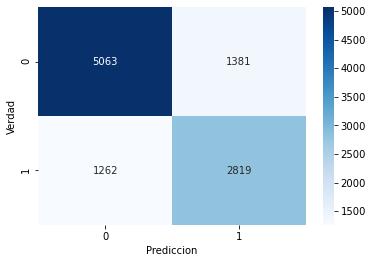

In [4]:
#creación del modelo
d_tree=DecisionTreeClassifier(max_depth=40)

#Entrenamiento del modelo
d_tree.fit(X_train, y_train)

#Predicción de los datos de entrenamiento
y_pred_train=d_tree.predict(X_train)

#Métricas de desempeño 
accuaracy_train=accuracy_score(y_train, y_pred_train)
print (f"El accuracy de entrenamiento es: {accuaracy_train}")

#Predicción de los datos de prueba
y_pred_ds=d_tree.predict(X_test)

#Métricas de desempeño 
accuaracy_ds=accuracy_score(y_test, y_pred_ds)
print (f"El accuracy prueba es: {accuaracy_ds}")

sns.heatmap(confusion_matrix(y_test, y_pred_ds),annot=True,fmt='g',cmap='Blues')
plt.xlabel('Prediccion')
plt.ylabel('Verdad')

Tomando como guía el ejemplo anterior, modifique parámetros como la profundidad del árbol de decisión. Varíe este parámetro al menos 4 veces entre los valores de 1 a 40. Para este punto debe mostrar el desempeño para cada caso. Tengan en cuenta como cambia el accuracy de entrenamiento y prueba para cada caso y el comportamiento de la matriz confusión. 

El accuracy de entrenamiento es: 0.7164528899445765
El accuracy prueba es: 0.723895486935867


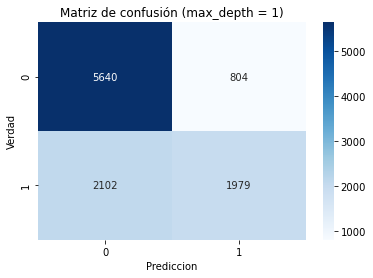

El accuracy de entrenamiento es: 0.7961995249406176
El accuracy prueba es: 0.7959144893111639


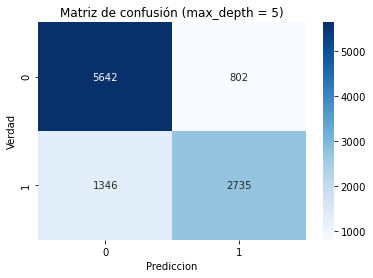

El accuracy de entrenamiento es: 0.8931433095803643
El accuracy prueba es: 0.7826128266033254


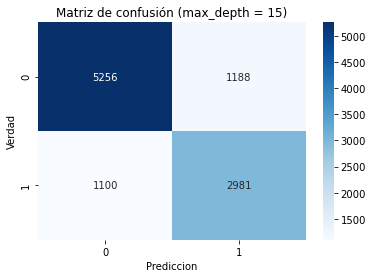

El accuracy de entrenamiento es: 0.9967062549485353
El accuracy prueba es: 0.746603325415677


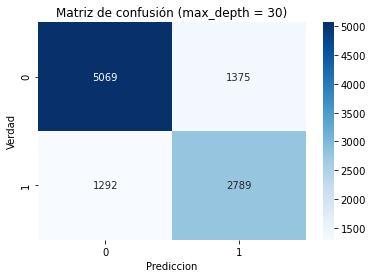


Resumen de resultados:
   max_depth  Accuracy Train  Accuracy Test
0          1        0.716453       0.723895
1          5        0.796200       0.795914
2         15        0.893143       0.782613
3         30        0.996706       0.746603


In [9]:
# =====================================================
# COMPLETAR ===========================================
# you code here

profundidades = [1,5,15,30]

resultados = []

for d in profundidades:
    
    #Definimos el modelo
    d_tree=DecisionTreeClassifier(max_depth=d)

    #Entrenamiento del modelo
    d_tree.fit(X_train, y_train)

    #Predicción de los datos de entrenamiento
    y_pred_train=d_tree.predict(X_train)

    #Métricas de desempeño 
    accuracy_train = accuracy_score(y_train, y_pred_train)
    print (f"El accuracy de entrenamiento es: {accuracy_train}")

    #Predicción de los datos de prueba
    y_pred_ds=d_tree.predict(X_test)

    #Métricas de desempeño 
    accuracy_ds = accuracy_score(y_test, y_pred_ds)
    print (f"El accuracy prueba es: {accuracy_ds}")
    
    #Guardar resultados
    resultados.append((d,accuracy_train,accuracy_ds))

    sns.heatmap(confusion_matrix(y_test, y_pred_ds),annot=True,fmt='g',cmap='Blues')
    plt.title(f"Matriz de confusión (max_depth = {d})")
    plt.xlabel('Prediccion')
    plt.ylabel('Verdad')
    plt.show()

resultados = pd.DataFrame(resultados,columns=["max_depth","Accuracy Train","Accuracy Test"])
print("\nResumen de resultados:")
print(resultados)
    
# =====================================================

Responda la siguientes preguntas:
1. ¿Cómo afecta la variación de estos parámetros en el desempeño del modelo? Justifique su respuesta
2. ¿Observa sobreajuste en algunos de los modelos? Justifique su respuesta
3. De las variaciones que aplicó el modelo de Arbol de desición ¿Cuál fué el modelo con mejor desempeño?

***RESPUESTAS***

1. ¿Cómo afecta la variación de estos parámetros en el desempeño del modelo? Justifique su respuesta: 

Cuando la profundidad es baja `max_depth = (1,5)` el árbol tiene poca capacidad de aprender reglas complejas, por lo que el accuracy de entrenamiento y prueba son bajos y similares, esto lo conocemos como subajuste.

Por otro lado, al incremar la profundidad `max_depth = (15,30,40)` el árbol memoriza cada vez mejor los datos de entrenamiento, como podemos observar en la tabla el Accuracy Train crece hasta 1.0, pero en los datos de Test el desempeño deja de mejorar e incluso empeora, ocurriendo nuevamente sobreajuste. 

Por lo tanto, podemos decir lo siguiente:

 * Baja profundidad = modelo simple, mal desempeño en general.
 * Alta profundidad = modelo muy complejo, aprende bien el entrenamiento pero pierde capacidad de generalización.
 * Profundidad intermedia = mejor balance entre ajuste y generalización.
 

2. ¿Observa sobreajuste en algunos de los modelos? Justifique su respuesta

Si, como mencionaba para `max_depth = 30`y `max_depth = 40`, el accuracy en entrenamiento es casi perfecto como se puede observar en la tabla (0.996706 - 1.0), pero el accuracy en prueba cae (0.746603,0.7488836104513064). Esa diferencia grande entre train y test es una señal clara de sobreajuste, el modelo memorizó el entrenamiento, pero no generaliza bien nuevos datos.


3. De las variaciones que aplicó el modelo de Arbol de desición ¿Cuál fué el modelo con mejor desempeño?

El mejor equilibrio se observa en  `max_depth = 5` donde:

 * Train = 0.796200
 * Test = 0.795914

Es el punto en el que el modelo aprende lo sufiente para predecir bien, pero sin caer en sobreajuste.


### Modelo 2: Regresión logística

Ahora se muestra un ejemplo de cómo aplicar un modelo de regresión logística para realizar la clasificación deseada. Observe que se crea el modelo, se hace el entrenamiento y se evalúa el desempeño del modelo para el conjunto de entrenamiento y prueba. Por último, se obtiene la matríz de confusión del modelo.

El accuracy de entrenamiento es: 0.7206650831353919
El accuracy de prueba es: 0.7273159144893112


Text(33.0, 0.5, 'Verdad')

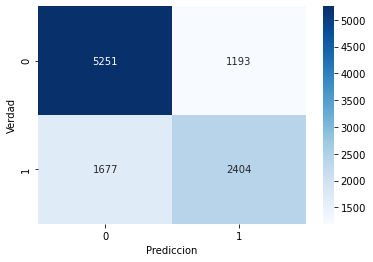

In [14]:

# Crear el modelo
model = LogisticRegression()

#Entrenamiento del modelo
model.fit(X_train, y_train)

#Predicción de los datos de entrenamiento
y_pred_train=model.predict(X_train)

#Métricas de desempeño 
accuaracy_train=accuracy_score(y_train, y_pred_train)
print (f"El accuracy de entrenamiento es: {accuaracy_train}")


#Predicción de los datos de prueba
y_pred_ds=model.predict(X_test)

#Métricas de desempeño
accuaracy_prueba=accuracy_score(y_test, y_pred_ds)
print (f"El accuracy de prueba es: {accuaracy_prueba}")

sns.heatmap(confusion_matrix(y_test, y_pred_ds),annot=True,fmt='g',cmap='Blues')
plt.xlabel('Prediccion')
plt.ylabel('Verdad')

Tomando como guía el ejemplo anterior, aplique el parámetro de regularización C al modelo de regresión lodística. Varíe este parámetro al menos 4 veces entre los valores de 0.01 a 100. Para este punto debe mostrar el desempeño para cada caso. Tengan en cuenta como cambia el accuracy de entrenamiento y prueba para cada caso y el comportamiento de la matriz confusión. 

In [15]:
# =====================================================
# COMPLETAR ===========================================
# 

# =====================================================

El accuracy de entrenamiento es: 0.7214568487727633
El accuracy de prueba es: 0.7280760095011877


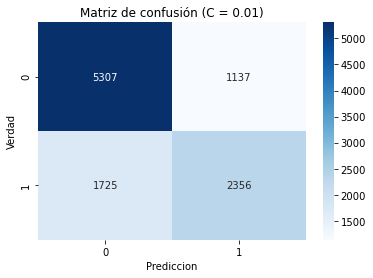

El accuracy de entrenamiento es: 0.7213935075217736
El accuracy de prueba es: 0.7280760095011877


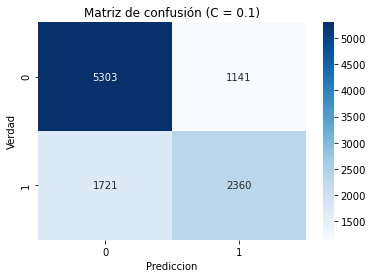

El accuracy de entrenamiento es: 0.7206650831353919
El accuracy de prueba es: 0.7273159144893112


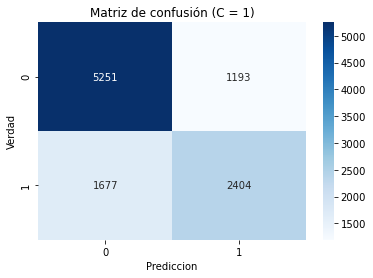

El accuracy de entrenamiento es: 0.7382739509105305
El accuracy de prueba es: 0.7433729216152019


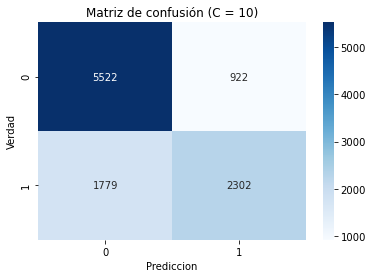

El accuracy de entrenamiento es: 0.7211401425178148
El accuracy de prueba es: 0.7264608076009501


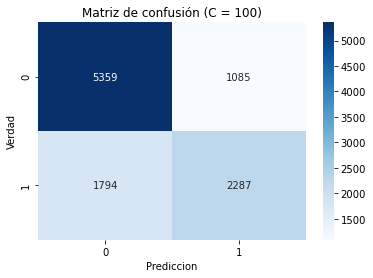


Resumen de comparativo:
        C  Accuracy Train  Accuracy Test
0    0.01        0.721457       0.728076
1    0.10        0.721394       0.728076
2    1.00        0.720665       0.727316
3   10.00        0.738274       0.743373
4  100.00        0.721140       0.726461


In [18]:
# =====================================================
# COMPLETAR ===========================================
# you code here

regulacion_C = [0.01, 0.1, 1, 10, 100]

resultados = []

for c in regulacion_C:
    
    # Crear el modelo
    model = LogisticRegression(C = c)

    #Entrenamiento del modelo
    model.fit(X_train, y_train)

    #Predicción de los datos de entrenamiento
    y_pred_train = model.predict(X_train)

    #Métricas de desempeño 
    accuracy_train = accuracy_score(y_train, y_pred_train)
    print (f"El accuracy de entrenamiento es: {accuracy_train}")
    
    #Predicción de los datos de prueba
    y_pred_ds = model.predict(X_test)

    #Métricas de desempeño
    accuracy_prueba = accuracy_score(y_test, y_pred_ds)
    print (f"El accuracy de prueba es: {accuracy_prueba}")
    
    #Guardar resultados    
    resultados.append((c,accuracy_train, accuracy_prueba))
                      
                      
    sns.heatmap(confusion_matrix(y_test, y_pred_ds),annot=True,fmt='g',cmap='Blues')
    plt.title(f"Matriz de confusión (C = {c})")
    plt.xlabel('Prediccion')
    plt.ylabel('Verdad')
    plt.show()

resultados = pd.DataFrame(resultados,columns=["C","Accuracy Train","Accuracy Test"])
print("\nResumen de comparativo:")
print(resultados)

# =====================================================

Responda la siguientes preguntas:

1. ¿Cómo afecta la variación de estos parámetros en el desempeño del modelo? Justifique su respuesta
2. ¿Observa sobreajuste en algunos de los modelos? Justifique su respuesta
3. Teniendo en cuenta los modelos de árbol de desición y regresión logística ¿Cuál fué el modelo con mejor desempeño?Justifique su respuesta
4. ¿De que otra manera cree que podría mejorar el desempeño de cada uno de los modelos trabajados durante este taller?

***RESPUESTAS***

1. ¿Cómo afecta la variación de estos parámetros en el desempeño del modelo? Justifique su respuesta

Cuando la variación de C es pequeña (0.01,0.1,1) la regularización es fuerte, esto quiere decir que el modelo es demasiado restringido y obtiene accuracies alrededor de (0.72-0.73) eso indica subajuste.

Por otro lado, cuando la variación de C = 10, el modelo logra aprender más patrones y alcanza su mejor desempeño como se observa en la tabla (train = 0.738274 , test = 0.743373). Sin embargo, cuando la variación de C = 100, la regularización prácticamente desaparece, pero el modelo no mejora el accuracy cae nuevamente como se observa en la tabla (train = 0.721140).

En conclusión, el valor de C controla la complejidad del modelo; valres bajos simplifican demasiado y valores intermedios permiten un mejor ajuste.


2. ¿Observa sobreajuste en algunos de los modelos? Justifique su respuesta

En los árboles de decision profundos (`max_depth = 30 y 40`) si existe sobreajuste, por el accuracy de entrenamiento es perfecto, pero el de prueba baja. Esa diferencia grande entre train y test es una señal clara de sobreajuste, el modelo memorizó el entrenamiento, pero no generaliza bien nuevos datos.

En regresió logística no se observa sobreajuste fuerte, ya que la diferencia entre entrenamiento y prueba es siempre muy pequeña. Aquí, el problema fue más bien subajuste, ya que cuando la regularización era muy fuerte la variación de C es pequeña. 


3. Teniendo en cuenta los modelos de árbol de desición y regresión logística ¿Cuál fué el modelo con mejor desempeño?Justifique su respuesta

El Árbol de Decisión con `max_depth = 5` fue el modelo con mejor desempeño global en este taller, ya que alcanzó un accuracy cercano a 0.796200 tanto en entrenamiento como en prueba, mostrando un buen balance entre ajuste y generalización.

En comparación, la regresión logística con C = 10 logró su mejor resultado con un accuracy de 0.743373 en prueba, lo cual es más bajo que el del árbol.

Esto indica que, para este problema en particular, el **Árbol de Decisión** fue más eficaz que la **Regresión Logística**, probablemente porque los patrones de cancelación de reservas no son lineales, y el árbol puede capturar relaciones más complejas entre las variables.

4. ¿De que otra manera cree que podría mejorar el desempeño de cada uno de los modelos trabajados durante este taller?

En árbol de decisión se podría:

* Implementar Random Forest o Gradient Boosting, que combinan varios árboles y reducen el riesgo de sobreajuste.

* Ajustar parámetros como `min_samples_split`, `min_samples_leaf` o aplicar poda del árbol.

* Usar validación cruzada para determinar la profundidad óptima del árbol.

En cuanto a regresión logística, podemos:

* Aplicar un escalado de variables (normalización/estandarización), ya que este modelo es sensible a la escala de los datos.

* Probar otros tipos de regularización (`L1 `o `ElasticNet` además de L2).

* Explorar más valores de `C` en un rango intermedio para afinar mejor el balance entre sesgo y varianza.

* Realizar selección de variables o ingeniería de características para que los predictores sean más informativos.

Ahora, de manera general para ambos podríamos:

* Implementar validación cruzada en lugar de una sola partición train/test.

* Manejar posibles desbalances de clase (si hay más cumplimientos que cancelaciones) usando técnicas como oversampling, undersampling o SMOTE.

